### Linear Regression

#### Exercise : hand coding the simplest case



You are given a list of coordinates and told that a best fit line would be one that passes through the origin.  Find the equation of the best fit. <br>
Concretely, given $(x_i, y_i)$, find the value of $a$ which minimizes $\sum(y_i-ax_i)^2$. 
In this case, the closed-form solution is $a=\frac{\sum_{i=1}^n x_i y_i}{\sum_{i=1}^n x_i^2}$ (you guys may do the derivative and set it to zero to obtain this solution). 
Write a function *best_fit* which takes two lists *x* and *y* and returns *a*. 

In [1]:
def best_fit(x,y):
    if len(x) != len(y):
        raise NameError("The data has the wrong shape")
    top=0
    for i in range(len(x)): 
        top=top+x[i]*y[i]
    bottom=0
    for i in range(len(x)): 
        bottom=bottom+x[i]*x[i]
    a=top/bottom
    return a

Alternative Solution


In [2]:
def best_fit_2(x_list, y_list):
    x = np.array(x_list)
    #x_mean=np.mean(x)
    y = np.array(y_list)
    #y_mean=np.mean(y)
    a = np.dot(x,y) / np.dot(x,x)
    #a =np.dot(x-x_mean) / np.dot (x-x_mean,x-x_mean)
    #b=y_mean-a*x_mean
    return a
    #return a,b

Remember that for standard one dimensional linear regression without intercept, the coefficient is quotient of the empirical covariance (between the dependent and independent variables) divided by the empirical variance (of the independent variable), i.e., $\beta_1^* = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}$, where $\frac{1}{n}$ is canceled out in the numerator and denominator. 

In [3]:
best_fit([1,2,4],[2,5,8])

2.0952380952380953

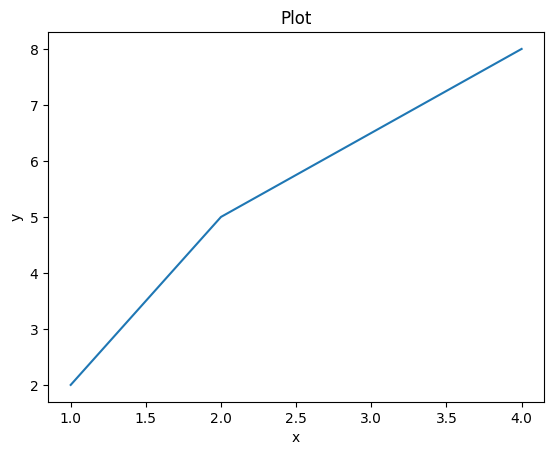

In [5]:
import matplotlib.pyplot as plt

x=[1,2,4]
y=[2,5,8]

plt.plot(x,y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Plot")
plt.show()

In [6]:
def regandplot(x,y):
    a=best_fit(x,y)
    plt.plot(x,y)
    ax=[a*i for i in x]
    plt.plot(x,ax)

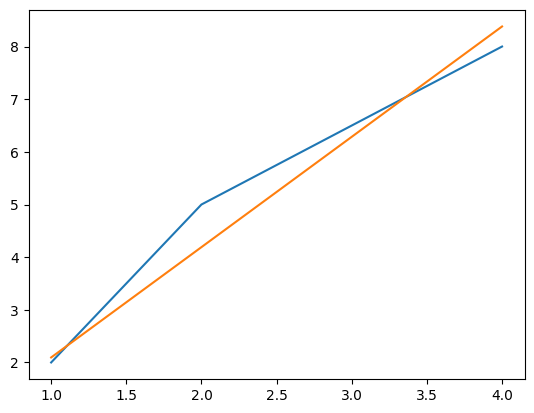

In [7]:
regandplot(x,y)

#### Inbuilt sklearn functions

You are given a list of coordinates and told that a best fit line would be one that passes through the origin.  Find the equation of the best fit. Concretely, given $(x_i, y_i)$, find the value of $a$ which minimizes $\sum(y_i-ax_i)^2$.  

In [11]:
import numpy as np
from sklearn.linear_model import LinearRegression
X = np.array([2,3,4]).reshape(3,1)
y = [7,10,11]
lr = LinearRegression()   # call an instance of the LinearRegression class 
lr.fit(X,y)    # fit the model, now the instance lr has attributes such as coefficients, intercepts etc. (they can be used for prediction later)
print(lr.coef_, lr.intercept_)

[2.] 3.3333333333333357


In [9]:
X = np.array([2,3,4]).reshape(3,1)
y = [7,10,11]
lr = LinearRegression(fit_intercept=False)  # do not include the intercept term
lr.fit(X,y)
print(lr.coef_, lr.intercept_)

[3.03448276] 0.0


In [10]:
print(lr.predict(np.array([[1]])))

[3.03448276]


#### Let's try this on a real dataset

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets

diab = datasets.load_diabetes()  #loading the diabetes dataset with the predefined function. Result is a "bunch" object

In [14]:
X = pd.DataFrame(data=diab.data, columns=diab.feature_names) # convert the bunch object's inputs to a dataframe
y = diab.target 
print(diab.DESCR)
X.head()

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


After some basic exploration, we notice that the variables "BMI" and "s5" seem to correlate to the target variable.  See the plots below:

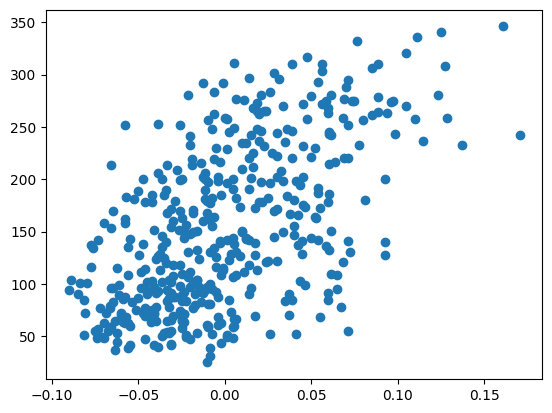

In [15]:
plt.scatter(X.bmi, y) #make a scatter plot of the feature BMI and the output
plt.show()

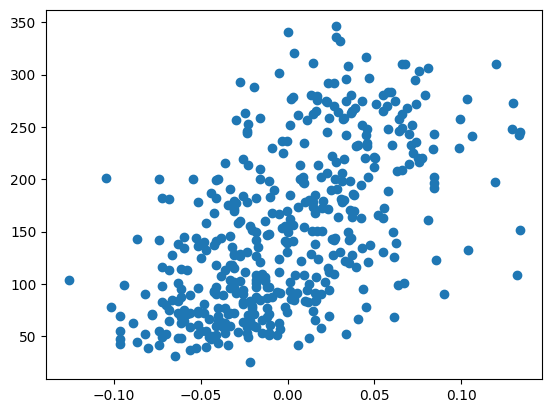

In [16]:
plt.scatter(X.s5, y) #same thing with feature s5
plt.show()

Hence, lets try to focus on building a simple model assuming the following form

$$
\text{desease progression} = w_0 + w_1 \times age + w_2 \times s5
$$

Recall the formula above to solve $\vec{w}$, what we need is the design matrix $\textbf{X}$ and the target values $\vec{y}$ <br>
To account for the presence of the intercept, we add a dummy feature equal to one for each instance, as was done in the class before. 

In [18]:
X = pd.DataFrame(data=diab.data, columns=diab.feature_names)
y = diab.target

X_features = X[["age", "s5"]].to_numpy()  #subsample the features I decided are important and make a numpy arraw with it
ones = np.ones(len(X)) #prepare the dummy feature equal to one everywhere. See slide 52 in the Linear Regression slides

X = np.c_[ones, X_features] #make an extended feature including the dummy feature, see slide 52 in the LR slides
X

array([[ 1.        ,  0.03807591,  0.01990749],
       [ 1.        , -0.00188202, -0.06833155],
       [ 1.        ,  0.08529891,  0.00286131],
       ...,
       [ 1.        ,  0.04170844, -0.04688253],
       [ 1.        , -0.04547248,  0.04452873],
       [ 1.        , -0.04547248, -0.00422151]], shape=(442, 3))

Plugging in all the righ-hand side of the closed-form solution we have in our slides, we can solve for $\vec{w}$ as the following

In [19]:
xTx_inv = np.linalg.inv ( np.dot ( np.transpose(X) , X ) ) # computing (X^tX)^{-1}. linalg=linar algebra. inv= inverse
xTy = np.dot ( np.transpose(X) , y)  #computing X^t y
w = np.dot( xTx_inv , xTy) #w=X^t (X^tX)^{-1}X^t y See slide 69 in linear regression
print(w)

[152.13348416  60.55660267 899.7402064 ]


#### Linear Regression: running the model with sklearn and printing simple performance scores


Lets now turn to using sklearn to perform similar calculations

In [20]:
X = pd.DataFrame(data=diab.data, columns=diab.feature_names)
y = diab.target

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn import preprocessing


lr = LinearRegression()
lr.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


We can look at the model parameters

In [22]:
print("Coefficients:\n", lr.coef_)

Coefficients:
 [ -10.0098663  -239.81564367  519.84592005  324.3846455  -792.17563855
  476.73902101  101.04326794  177.06323767  751.27369956   67.62669218]


In [23]:
print("Intercept:\n", lr.intercept_)

Intercept:
 152.13348416289597


#### Regression Visualization

We now plot the data and the regression line with matplotlib

C:\Users\Durga\AppData\Local\Temp\ipykernel_10332\3837820043.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lx = np.arange(min(x), max(x), (max(x) - min(x)) / 200).reshape(200, 1) #choosing the X's to apply the function to so I can plot the function. the number of steps isn't very important


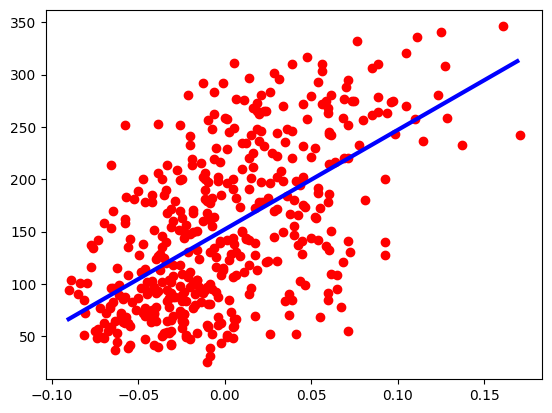

In [24]:
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn import linear_model

diabetes = datasets.load_diabetes()
x = diabetes.data[:,2][:,np.newaxis]
y = diabetes.target
regr = linear_model.LinearRegression()
regr.fit(x, y)

plt.scatter(x, y, color = 'red') #plotting the observations
lx = np.arange(min(x), max(x), (max(x) - min(x)) / 200).reshape(200, 1) #choosing the X's to apply the function to so I can plot the function. the number of steps isn't very important
plt.plot(lx, regr.predict(lx), color='blue', linewidth = 3) #plotting the function chosen by the algorithm
plt.show()

We now provide a similar plot when we perform regression based on two variables. We thus obtain a 3D plot. 

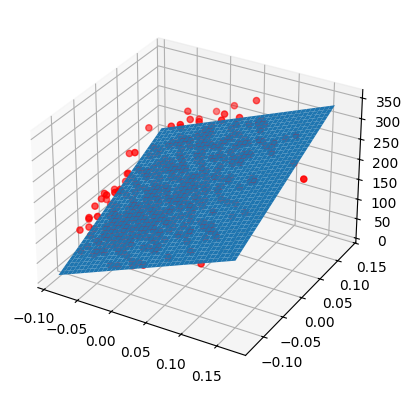

In [25]:
from mpl_toolkits.mplot3d import Axes3D

x = diabetes.data[:,[2,8]]  #loading data with just features 2 and 8
y = diabetes.target  #loading the labels
regr = linear_model.LinearRegression()  #declare an instance of the model class
regr.fit(x, y)    #fitting the model
steps = 40
lx0 = np.arange(min(x[:,0]), max(x[:,0]), (max(x[:,0]) - min(x[:,0])) / steps).reshape(steps,1) #making a mesh of 2d input space
lx1 = np.arange(min(x[:,1]), max(x[:,1]), (max(x[:,1]) - min(x[:,1])) / steps).reshape(steps,1)#making a mesh of 2d input space
xx0, xx1 = np.meshgrid(lx0, lx1)  #making a mesh of 2d input space
xx = np.zeros(shape = (steps,steps,2)) #initializing 
xx[:,:,0] = xx0
xx[:,:,1] = xx1
x_stack = xx.reshape(steps ** 2, 2)  #the predict method only works on two dimensional arrays so we need to reshape the input
y_stack = regr.predict(x_stack)
yy = y_stack.reshape(steps, steps)  #to make the graph we need to shape the output back into a 3d array

fig = plt.figure()
ax = plt.axes(projection = '3d')
ax.scatter3D(x[:,0], x[:,1], y, color = 'red')
ax.plot_surface(xx0, xx1, yy, rstride=1, cstride=1)
plt.show()

####  Does the magnitude of coefficient represent feature importance?

Now let's run the linear regression model with all the variables there and print the coefficients. We then investigate how one coefficient changes if the feature to which it corresponds is multiplied or divided by a constant: let us divide the column "AGE" by 1000 and run the model again. What happened to the coefficients? 

In [26]:
from sklearn import linear_model

X = pd.DataFrame(data=diab.data, columns=diab.feature_names)
y = diab.target

lin_reg = linear_model.LinearRegression()
lin_reg.fit(X,y)

lin_reg.coef_

array([ -10.0098663 , -239.81564367,  519.84592005,  324.3846455 ,
       -792.17563855,  476.73902101,  101.04326794,  177.06323767,
        751.27369956,   67.62669218])

Suppose I change the scale of the values for X.age by dividing by 10000, then the coefficient would increase by the same order of magnitude, as shown below. This is true exactly, not just approximately. Indeed, linear regression only cares about the loss, it is free to choose any set of weights: the same function as above can now be represented with the first coefficient being multiplied by 10000 to accound for the data being 10000 times smaller. Since the model doesn't care about the weights, the same function is still the same one, so it will update the weight to make up for the scaling in the data.

In [27]:
X = pd.DataFrame(data=diab.data, columns=diab.feature_names)
y = diab.target

X.age = X.age/10000

lin_reg = linear_model.LinearRegression()
lin_reg.fit(X,y)

lin_reg.coef_

array([-1.00098663e+05, -2.39815644e+02,  5.19845920e+02,  3.24384646e+02,
       -7.92175639e+02,  4.76739021e+02,  1.01043268e+02,  1.77063238e+02,
        7.51273700e+02,  6.76266922e+01])

This means that if we have such features in the datasets, the model will pay more attention to these features, leading to a modeling biased toward those features (e.g., overfitting to these features).

#### Polynomial Regression

Next let's try polynomial regression. We can start with datasets having more complex patterns.

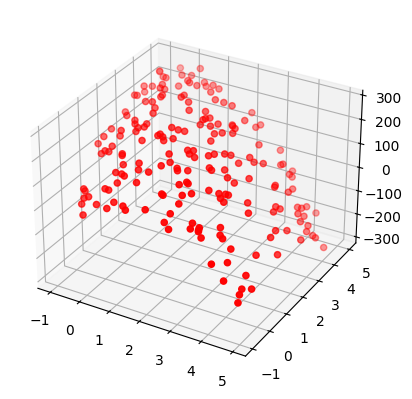

In [28]:
from sklearn import preprocessing

np.random.seed(2020)
n = 200
x = np.random.rand(n, 2) * 6 - 1  #random inputs. Remember np.random.rand outputs numbers from a uniform distribution from 0 to 1
y = - 24 * x[:,0] ** 2 - 12 * x[:,1] ** 2 - 15 * x[:,0] * x[:,1] + 70 * x[:,0] + 90 * x[:,1] + 10 * np.random.randn(n) + 100  #making labels which are a polynomial function of the inputs plus some independent noise.

fig = plt.figure()
ax = plt.axes(projection = '3d')
ax.scatter3D(x[:,0], x[:,1], y, color = 'red')
plt.show()

In [29]:
poly2 = preprocessing.PolynomialFeatures(2)
x2 = poly2.fit_transform(x)  #this is where feature transformation, including the kernel trick magic, takes place! Look at our slide for a detailed explanation of what the transform is doing

regr2 = linear_model.LinearRegression()
regr2.fit(x2, y)

print(regr2.coef_)
print(poly2.powers_)  #there is a function which gives you the powers that the coefficients correspond to. 

[  0.          69.4348825   89.4880611  -23.95730288 -14.83983042
 -11.91885441]
[[0 0]
 [1 0]
 [0 1]
 [2 0]
 [1 1]
 [0 2]]


In [30]:
regr2_no_intercept = linear_model.LinearRegression(fit_intercept=False)
regr2_no_intercept.fit(x2, y)

print('-- with intercept --')
print('Coefficients:', regr2.coef_)
print('Intercept:', regr2.intercept_)

print('-- with no intercept --')
print('Coefficients:', regr2_no_intercept.coef_)
print('Intercept:', regr2_no_intercept.intercept_)

-- with intercept --
Coefficients: [  0.          69.4348825   89.4880611  -23.95730288 -14.83983042
 -11.91885441]
Intercept: 100.32433944311285
-- with no intercept --
Coefficients: [100.32433944  69.4348825   89.4880611  -23.95730288 -14.83983042
 -11.91885441]
Intercept: 0.0


Note in the two examples above that we have the same coefficients except for the intercept. Fitting with or without intercept is equivalent in polynomial regression with sklearn, because the polynomial transform already includes a constant dummy feature. Therefore, LinearRegression has two ways to represent constants (intercepts): as an intercept in the LinearRegression method, and as a coefficient that multiplies the dummy variable. In the first case, the model chose to use the intercept from the linear regression method, whereas in the second case it had to use the dummy variable since we didn't seperately fit an intercept. The function is the SAME. That would be true even if we had 50/50 between the dummy feature and the lr intercept. The choice made in the first case is due to the programming choice and optimization method in the sklearn function. 